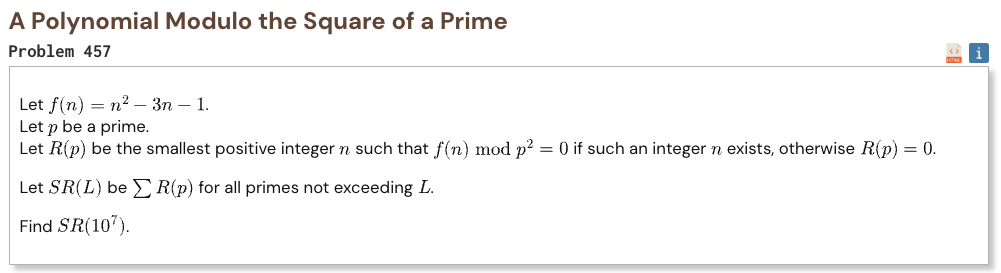

## Initial approach

-   rewrite the quadratic so solving it becomes finding a square root of 13 modulo each prime
-   only primes where 13 is a quadratic residue can have a valid answer
-   use quadratic reciprocity to skip primes outside six useful residue classes modulo 13
-   find a square root of 13 modulo each remaining prime with the Tonelli Shanks algorithm
-   convert the two square roots into the two possible roots of the original polynomial modulo the prime
-   lift each root from modulo p to modulo p squared using one Hensel step
-   choose the smaller positive lifted root and add it to the total

In [1]:
%%time

LIMIT = 10**7

def prime_sieve(n):
    sieve = bytearray(b"\x01") * (n + 1)
    sieve[0:2] = b"\x00\x00"

    limit = int(n**0.5)

    for p in range(2, limit + 1):
        if sieve[p]:
            start = p * p
            sieve[start:n + 1:p] = b"\x00" * (((n - start) // p) + 1)

    return sieve

def tonelli_shanks(n, p):
    if n == 0:
        return 0

    if p == 2:
        return n

    if pow(n, (p - 1) // 2, p) != 1:
        return None

    if p % 4 == 3:
        return pow(n, (p + 1) // 4, p)

    q = p - 1
    s = 0

    while q % 2 == 0:
        q //= 2
        s += 1

    z = 2

    while pow(z, (p - 1) // 2, p) != p - 1:
        z += 1

    c = pow(z, q, p)
    x = pow(n, (q + 1) // 2, p)
    t = pow(n, q, p)
    m = s

    while t != 1:
        i = 1
        temp = t * t % p

        while temp != 1:
            temp = temp * temp % p
            i += 1

        b = pow(c, 1 << (m - i - 1), p)

        x = x * b % p
        t = t * b * b % p
        c = b * b % p
        m = i

    return x

def lift_root(r, p):
    f = r * r - 3 * r - 1
    derivative = (2 * r - 3) % p
    correction = (-(f // p) * pow(derivative, -1, p)) % p

    return r + correction * p

def R(p):
    if p == 2 or p == 13:
        return 0

    if p % 13 not in {1, 3, 4, 9, 10, 12}:
        return 0

    root13 = tonelli_shanks(13, p)

    if root13 is None:
        return 0

    inv2 = (p + 1) // 2

    r1 = ((3 + root13) * inv2) % p
    r2 = ((3 - root13) * inv2) % p

    n1 = lift_root(r1, p)
    n2 = lift_root(r2, p)

    return min(n1, n2)

sieve = prime_sieve(LIMIT)

result = 0

for p in range(2, LIMIT + 1):
    if sieve[p]:
        result += R(p)

print("Result:", result)

Result: 2647787126797397063
CPU times: user 1.84 s, sys: 11.4 ms, total: 1.85 s
Wall time: 1.85 s
